# Keep-alive

In [ ]:
%%javascript
function ClickConnect(){
    console.log("Keeping alive");
    document.querySelector("colab-toolbar-button#connect").click()
}
setInterval(ClickConnect, 60000)

<IPython.core.display.Javascript object>

# Mount Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Install and Imports

In [ ]:
!pip install shap --quiet

import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, LSTM, GRU, Dense, Dropout,
    Bidirectional, Multiply, Permute,
    RepeatVector, Flatten, Activation,
    Lambda
)
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: []


# Configuration

In [ ]:
# Options: 'baseline', 'bilstm', 'attention', 'gru'
MODEL_TYPE = 'attention'
# Paths
CSV_PATH    = '/content/drive/MyDrive/DMIF/master_dataset_clean_80.csv'
LOCAL_CSV   = '/content/master_dataset.csv'
MODELS_DIR  = '/content/drive/MyDrive/DMIF/models'
os.makedirs(MODELS_DIR, exist_ok=True)

# Model save paths
SAVE_PATHS = {
    'baseline'  : f'{MODELS_DIR}/lstm_baseline.keras',
    'bilstm'    : f'{MODELS_DIR}/lstm_bilstm.keras',
    'attention' : f'{MODELS_DIR}/lstm_attention.keras',
    'gru'       : f'{MODELS_DIR}/lstm_gru.keras'
}
SAVE_PATH = SAVE_PATHS[MODEL_TYPE]

# Training config
SEQ_LEN      = 30
BATCH_SIZE   = 64
EPOCHS       = 50
DROPOUT      = 0.3
LSTM_UNITS   = [64, 32]

# Class weights to fix imbalance (UP 34.6% / DOWN 65.4%)
CLASS_WEIGHT = {0: 1.0, 1: 1.89}

# LSTM features — 30 features
LSTM_FEATURES = [
    'Open', 'High', 'Low', 'Close', 'Log_Volume',
    'Daily_Return', 'Log_Return', 'HL_Range', 'OC_Range',
    'MA_24', 'MA_30', 'MA_500',
    'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist',
    'BB_Upper', 'BB_Lower', 'BB_Middle', 'BB_Width',
    'Volatility_10', 'SAR', 'SAR_Trend',
    'Fib_0236', 'Fib_0382', 'Fib_05', 'Fib_0618', 'Fib_0786',
    'Volume_MA_10', 'Volume_Ratio'
]

print(f"Model type : {MODEL_TYPE}")
print(f"Save path  : {SAVE_PATH}")
print(f"Features   : {len(LSTM_FEATURES)}")
print(f"Input shape: ({SEQ_LEN}, {len(LSTM_FEATURES)})")

Model type : attention
Save path  : /content/drive/MyDrive/DMIF/models/lstm_attention.keras
Features   : 30
Input shape: (30, 30)


# loads the saved model

In [ ]:
# ── Load Already-Trained Model (skip training) ──────────────────
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Dropout, Bidirectional,
    Multiply, Flatten, Activation, Reshape,
    GlobalAveragePooling1D
)
import tensorflow as tf

def build_attention_lstm(seq_len, n_features):
    """Rebuilds the exact attention architecture — used to safely load weights only"""
    inp = Input(shape=(seq_len, n_features))
    x   = LSTM(64, return_sequences=True)(inp)
    x   = Dropout(0.3)(x)
    x   = LSTM(32, return_sequences=True)(x)
    x   = Dropout(0.3)(x)
    attention = Dense(1, activation='tanh')(x)
    attention = Flatten()(attention)
    attention = Activation('softmax')(attention)
    attention = Reshape((seq_len, 1))(attention)
    x   = Multiply()([x, attention])
    x   = GlobalAveragePooling1D()(x)
    x   = Dense(32, activation='relu')(x)
    x   = Dropout(0.15)(x)
    out = Dense(1, activation='sigmoid')(x)
    return Model(inp, out, name='LSTM_Attention')

print(f"Loading saved model: {SAVE_PATH}")

if MODEL_TYPE == 'attention':
    # Rebuild architecture fresh, then load only the weights
    # (avoids the kernel-crashing custom-layer deserialization issue)
    model = build_attention_lstm(SEQ_LEN, len(LSTM_FEATURES))
    model.load_weights(SAVE_PATH)
    print("✓ Attention model rebuilt and weights loaded — skipping training")
else:
    model = load_model(SAVE_PATH)
    print("✓ Model loaded — skipping training")

model.summary()

Loading saved model: /content/drive/MyDrive/DMIF/models/lstm_attention.keras
✓ Attention model rebuilt and weights loaded — skipping training


Model: "LSTM_Attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 30, 30)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 30, 64)    │     24,320 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 30, 64)    │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 30, 32)    │     12,416 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 30, 32)    │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 30, 1)     │         33 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 30)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 30)        │          0 │ flatten[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 30, 1)     │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 30, 32)    │          0 │ dropout_1[0][0],  │
│                     │                   │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ multiply[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      1,056 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         33 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 37,858 (147.88 KB)

 Trainable params: 37,858 (147.88 KB)

 Non-trainable params: 0 (0.00 B)

# Load and Preprocess Data

In [ ]:
import shutil

print("Copying CSV to local disk...")
shutil.copy(CSV_PATH, LOCAL_CSV)

df = pd.read_csv(LOCAL_CSV, parse_dates=['Date'])
df = df.sort_values(['Company_Code', 'Date']).reset_index(drop=True)

print(f"Loaded: {df.shape[0]} rows, {df['Company_Code'].nunique()} companies")

# ── Build sequences per company ───────────────────────────────
all_X, all_y = [], []
scalers = {}

companies = sorted(df['Company_Code'].unique())

for company in companies:
    company_df = df[df['Company_Code'] == company].copy()
    company_df = company_df.sort_values('Date').reset_index(drop=True)

    # Drop rows where any feature is NaN
    company_df = company_df.dropna(subset=LSTM_FEATURES + ['Target'])

    if len(company_df) < SEQ_LEN + 1:
        continue

    # Scale features — fit on training portion only (70%)
    train_end = int(len(company_df) * 0.7)
    scaler = MinMaxScaler()
    scaler.fit(company_df[LSTM_FEATURES].iloc[:train_end])
    scalers[company] = scaler

    scaled = scaler.transform(company_df[LSTM_FEATURES])
    targets = company_df['Target'].values

    # Build sliding windows
    for i in range(SEQ_LEN, len(company_df) - 1):
        all_X.append(scaled[i-SEQ_LEN:i])
        all_y.append(targets[i])

all_X = np.array(all_X, dtype=np.float32)
all_y = np.array(all_y, dtype=np.float32)

print(f"\nTotal sequences : {len(all_X)}")
print(f"Input shape     : {all_X.shape}")
print(f"UP  labels      : {all_y.sum():.0f} ({all_y.mean()*100:.1f}%)")
print(f"DOWN labels     : {(1-all_y).sum():.0f} ({(1-all_y).mean()*100:.1f}%)")

Copying CSV to local disk...
Loaded: 323998 rows, 80 companies

Total sequences : 321518
Input shape     : (321518, 30, 30)
UP  labels      : 112904 (35.1%)
DOWN labels     : 208614 (64.9%)


# Train/Val/Test Split

In [ ]:
n = len(all_X)
train_end = int(n * 0.70)
val_end   = int(n * 0.80)

X_tr = all_X[:train_end]
y_tr = all_y[:train_end]
X_va = all_X[train_end:val_end]
y_va = all_y[train_end:val_end]
X_te = all_X[val_end:]
y_te = all_y[val_end:]

print(f"Train : {X_tr.shape} | UP: {y_tr.mean()*100:.1f}%")
print(f"Val   : {X_va.shape} | UP: {y_va.mean()*100:.1f}%")
print(f"Test  : {X_te.shape} | UP: {y_te.mean()*100:.1f}%")

Train : (225062, 30, 30) | UP: 34.3%
Val   : (32152, 30, 30) | UP: 37.6%
Test  : (64304, 30, 30) | UP: 36.8%


# Threshold Tuning

In [ ]:
# ── Threshold Tuning on Validation Set (macro F1 — balances both classes) ─
from sklearn.metrics import f1_score
import numpy as np

va_probs = model.predict(X_va, verbose=0).flatten()

best_thresh, best_macro_f1 = 0.5, 0
for thresh in np.arange(0.30, 0.71, 0.01):
    preds = (va_probs >= thresh).astype(int)
    macro_f1 = f1_score(y_va, preds, average='macro')
    if macro_f1 > best_macro_f1:
        best_macro_f1, best_thresh = macro_f1, thresh

default_macro_f1 = f1_score(y_va, (va_probs >= 0.5).astype(int), average='macro')

print(f"Best threshold (macro F1) : {best_thresh:.2f}")
print(f"Macro F1 at best threshold: {best_macro_f1:.4f}")
print(f"Macro F1 at default 0.5   : {default_macro_f1:.4f}")

Best threshold (macro F1) : 0.48
Macro F1 at best threshold: 0.5284
Macro F1 at default 0.5   : 0.3844


# Evaluate

In [ ]:
# ── Evaluate Loaded Model — Full Metrics ─────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)

tr_probs = model.predict(X_tr, verbose=0).flatten()
va_probs = model.predict(X_va, verbose=0).flatten()
te_probs = model.predict(X_te, verbose=0).flatten()

tr_preds = (tr_probs >= 0.5).astype(int)
va_preds = (va_probs >= 0.5).astype(int)
te_preds = (te_probs >= best_thresh).astype(int)

tr_acc = accuracy_score(y_tr, tr_preds)
va_acc = accuracy_score(y_va, va_preds)
te_acc = accuracy_score(y_te, te_preds)

# Test-set detailed metrics
precision = precision_score(y_te, te_preds)
recall    = recall_score(y_te, te_preds)
f1        = f1_score(y_te, te_preds)
roc_auc   = roc_auc_score(y_te, te_probs)
cm        = confusion_matrix(y_te, te_preds)

print(f"MODEL: {MODEL_TYPE.upper()}")
print(f"Train Accuracy : {tr_acc:.4f}")
print(f"Val   Accuracy : {va_acc:.4f}")
print(f"Test  Accuracy : {te_acc:.4f}")
print(f"Precision (UP) : {precision:.4f}")
print(f"Recall    (UP) : {recall:.4f}")
print(f"F1-Score  (UP) : {f1:.4f}")
print(f"ROC-AUC        : {roc_auc:.4f}")
print("\nFull Classification Report:")
print(classification_report(y_te, te_preds, target_names=['DOWN', 'UP']))
print("Confusion Matrix (rows=actual, cols=predicted):")
print(cm)

MODEL: ATTENTION
Train Accuracy : 0.6572
Val   Accuracy : 0.6243
Test  Accuracy : 0.5658
Precision (UP) : 0.4052
Recall    (UP) : 0.3824
F1-Score  (UP) : 0.3935
ROC-AUC        : 0.5438

Full Classification Report:
              precision    recall  f1-score   support

        DOWN       0.65      0.67      0.66     40620
          UP       0.41      0.38      0.39     23684

    accuracy                           0.57     64304
   macro avg       0.53      0.53      0.53     64304
weighted avg       0.56      0.57      0.56     64304

Confusion Matrix (rows=actual, cols=predicted):
[[27329 13291]
 [14628  9056]]


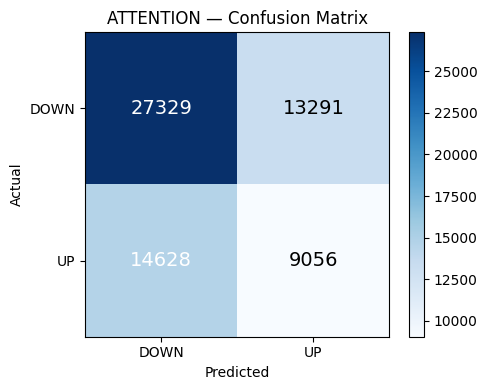

Saved: /content/drive/MyDrive/DMIF/models/attention_confusion_matrix.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')

for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=14)

ax.set_xticks([0, 1]); ax.set_xticklabels(['DOWN', 'UP'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['DOWN', 'UP'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'{MODEL_TYPE.upper()} — Confusion Matrix')
plt.colorbar(im)
plt.tight_layout()

cm_path = f'{MODELS_DIR}/{MODEL_TYPE}_confusion_matrix.png'
plt.savefig(cm_path)
plt.show()
print(f"Saved: {cm_path}")

# Save Results Summary

In [ ]:
import json

results = {
    'model_type'        : MODEL_TYPE,
    'train_accuracy'    : float(tr_acc),
    'val_accuracy'      : float(va_acc),
    'test_accuracy'     : float(te_acc),
    'precision_up'      : float(precision),
    'recall_up'         : float(recall),
    'f1_score_up'       : float(f1),
    'roc_auc'           : float(roc_auc),
    'confusion_matrix'  : cm.tolist(),
    'default_threshold_results': {
        'accuracy': float(accuracy_score(y_te, (te_probs >= 0.5).astype(int)))
    },
    'best_threshold'    : float(best_thresh),
    'best_threshold_macro_f1_val': float(best_macro_f1),
    'train_samples'     : int(len(X_tr)),
    'val_samples'       : int(len(X_va)),
    'test_samples'      : int(len(X_te)),
    'features'          : len(LSTM_FEATURES),
    'seq_len'           : SEQ_LEN,
    'class_weight'      : CLASS_WEIGHT
}

results_path = f'{MODELS_DIR}/{MODEL_TYPE}_results.json'
with open(results_path, 'w') as f:
    json.dump(results, f, indent=2)

print(f"Results saved: {results_path}")
print(json.dumps(results, indent=2))

Results saved: /content/drive/MyDrive/DMIF/models/attention_results.json
{
  "model_type": "attention",
  "train_accuracy": 0.6572411157814291,
  "val_accuracy": 0.6243468524508584,
  "test_accuracy": 0.5658279422741975,
  "precision_up": 0.4052445518414105,
  "recall_up": 0.38236784326971796,
  "f1_score_up": 0.3934739631987139,
  "roc_auc": 0.5438492807938696,
  "confusion_matrix": [
    [
      27329,
      13291
    ],
    [
      14628,
      9056
    ]
  ],
  "default_threshold_results": {
    "accuracy": 0.6316869868126399
  },
  "best_threshold": 0.48000000000000015,
  "best_threshold_macro_f1_val": 0.5283534962427264,
  "train_samples": 225062,
  "val_samples": 32152,
  "test_samples": 64304,
  "features": 30,
  "seq_len": 30,
  "class_weight": {
    "0": 1.0,
    "1": 1.89
  }
}
